<a href="https://colab.research.google.com/github/Manish927/EDA-Data-Science/blob/main/ML-Models/Linear-Regressionlinear_regression_activity_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np; import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [6]:
college = pd.read_excel('/content/college_dataset.xlsx'); college.sample(10)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
143,Columbia College,Yes,737,614,242,21,67,968,237,10425,3975,500,1500,61,77,14.7,34,8693,76
575,Sweet Briar College,Yes,462,402,146,36,68,527,41,14500,6000,500,600,91,99,6.5,48,18953,61
719,Wagner College,Yes,1416,1015,417,10,44,1324,117,13500,5800,585,1700,67,78,13.2,23,9006,75
560,SUNY at Albany,No,13528,9198,1843,16,61,10168,1231,6550,4355,700,1560,93,96,17.4,16,9075,74
249,Hartwick College,Yes,2083,1725,430,22,49,1464,67,17480,4780,500,700,75,87,12.3,32,11625,73
296,Knox College,Yes,1040,845,286,48,77,967,24,15747,4062,400,800,88,95,12.7,33,13224,79
722,Warren Wilson College,Yes,440,311,112,25,49,466,7,10000,3052,400,1100,65,75,11.4,20,9430,63
619,University of Florida,No,12445,8836,3623,54,85,24470,3286,7090,4180,630,1530,88,97,13.4,20,14737,66
733,Wellesley College,Yes,2895,1249,579,80,96,2195,156,18345,5995,500,700,94,98,10.6,51,21409,91
586,Texas Wesleyan University,Yes,592,501,279,19,44,1204,392,6400,3484,600,1800,80,83,14.5,10,7936,43


In [3]:
college.shape

(777, 19)

In [4]:
college.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

# Task 1
### Data Cleaning
- Check for missing values
- Remove the column containing university names
- Do not perform any additional cleaning

In [8]:
##### CODE HERE #####
college.isnull().sum()
if 'Unnamed: 0' in college.columns:
    college.drop('Unnamed: 0', axis=1, inplace=True)

college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


# Task 2
### Statistics Analysis
- Generate descriptive statistics for numeric columns
- Compute Pearson correlation between numerical features and identify the pair of features that are most correlated

In [9]:
##### CODE HERE #####
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


In [20]:
# Compute Pearson correlation matrix
corr_matrix = college.corr(numeric_only=True)
corr_matrix

# Find the pair of features with the highest correlation (excluding self-correlation)
corr_pairs = corr_matrix.abs().unstack()
corr_pairs

corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.drop_duplicates()

most_correlated_pair = corr_pairs.idxmax()
highest_corr_value = corr_pairs.max()

print("Most correlated pair:", most_correlated_pair)
print("Correlation value:", highest_corr_value)

Most correlated pair: ('Enroll', 'F.Undergrad')
Correlation value: 0.964639651952242


# Task 3
### Target Variable
- Set `Grad.Rate` as the target variable
- All other columns are treated as predictors

In [21]:
##### CODE HERE #####
y = college['Grad.Rate']
X = college.drop('Grad.Rate', axis=1)

print("Predictors shape:", X.shape)
print("Target shape:", y.shape)

Predictors shape: (777, 17)
Target shape: (777,)


# Task 4
### Data Preprocessing
- Do not scale or normalise the data
- Convert categorical variables into numeric format using one-hot encoding with `pd.get_dummies()` with `drop_first = True` to avoid multicollinearity

In [22]:
##### CODE HERE #####
X = pd.get_dummies(X, drop_first=True)
X.head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Private_Yes
0,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,True
1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,True
2,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,True
3,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,True
4,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,True


# Task 5
### Train-Validation Split
- Split the data into training (70%) and validation (30%) sets using `train_test_split()` with `random_state = 42` for reproducibility

In [24]:
##### CODE HERE #####
# Split the data into training (70%) and validation (30%) sets using train_test_split() with random_state = 42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_test.shape)


X_train shape: (543, 17)
X_val shape: (234, 17)
y_train shape: (543,)
y_val shape: (234,)


# Task 6
### Model Training
- Fit a linear regression model on the training data using `LinearRegression()` from `sklearn`

In [25]:
##### CODE HERE #####
# Fit a linear regression model on the training data using LinearRegression() from sklearn
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# Task 7
### Model Parameters
- Display model coefficients and intercept values using the attributes `.coef_` and `.intercept_`

In [26]:
##### CODE HERE #####
# Display model coefficients and intercept values using the attributes .coef_ and .intercept_
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)



Model coefficients: [ 1.52372919e-03 -1.37974487e-03  2.04218073e-03  3.35374363e-02
  1.44385338e-01 -1.83092082e-04 -2.00268302e-03  7.04378163e-04
  2.15058173e-03 -1.92139009e-03 -1.83456063e-03  1.41736811e-01
 -1.11153152e-01 -2.82926503e-02  3.37610792e-01 -5.32089945e-04
  5.05056314e+00]
Model intercept: 34.93871250622216


In [27]:
print("Intercept:", model.intercept_)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coefficients

Intercept: 34.93871250622216


,Feature,Coefficient
0,Apps,0.001524
1,Accept,-0.001380
2,Enroll,0.002042
3,Top10perc,0.033537
4,Top25perc,0.144385
5,F.Undergrad,-0.000183
6,P.Undergrad,-0.002003
7,Outstate,0.000704
8,Room.Board,0.002151
9,Books,-0.001921


# Task 8
### Predictions
- Generate predictions on both training and testing sets

In [28]:
##### CODE HERE #####
# Generate predictions on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Task 9
### Model Performance
- Evaluate model performance using R² and MAE on both training and testing sets

In [29]:
##### CODE HERE #####
# Evaluate model performance using R² and MAE on both training and testing sets
print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_test_pred))

print("Train MAE:", mean_absolute_error(y_train, y_train_pred))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Train R2: 0.46281446668115334
Test R2: 0.4355134100083745
Train MAE: 9.369761546299026
Test MAE: 9.59748917845442


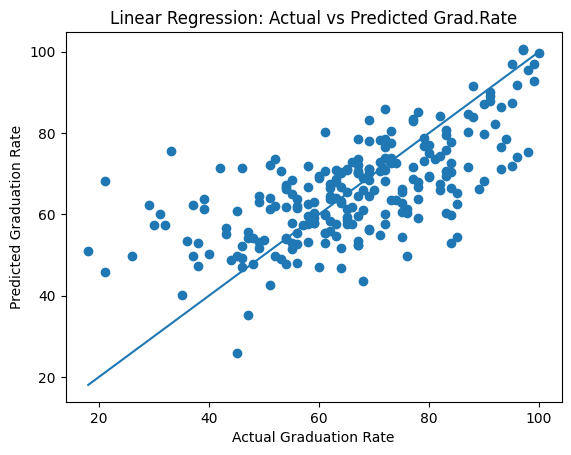

In [33]:
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(X_test)

# Scatter plot
plt.figure()
plt.scatter(y_test, y_pred)

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel("Actual Graduation Rate")
plt.ylabel("Predicted Graduation Rate")
plt.title("Linear Regression: Actual vs Predicted Grad.Rate")

plt.show()